# 1D Heat Equation: Development & Verification
This notebook covers the full workflow for implementing the **Implicit 1D Heat Equation**:
1. **Development**: Prototype and refine the numerical algorithm using Python/NumPy.
2. **Verification**: Confirm that the ported C++ backend matches the source prototype exactly.

The Heat Equation is given by:
$$\frac{\partial T}{\partial t} = \alpha \frac{\partial^2 T}{\partial x^2}$$

We use the **Implicit Backward Euler** scheme for unconditional stability.

## Part 1: Numerical Development (Python Prototyping)
In this phase, we develop and test the core logic in a high-level environment before bringing it to the C++ core.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Parameters
nx = 100
length = 1.0
dx = length / (nx - 1)
alpha = 0.05
dt = 0.05       
steps = 50

# Initial condition (Gaussian pulse with zeroed boundaries)
x = np.linspace(0, length, nx)
u0 = np.exp(-100.0 * (x - 0.5)**2)
u0[0] = 0.0
u0[-1] = 0.0

print(f"Prototyping Run: alpha={alpha}, nx={nx}, steps={steps}, total_time={steps*dt:.3f}s")

Prototyping Run: alpha=0.05, nx=100, steps=50, total_time=2.500s


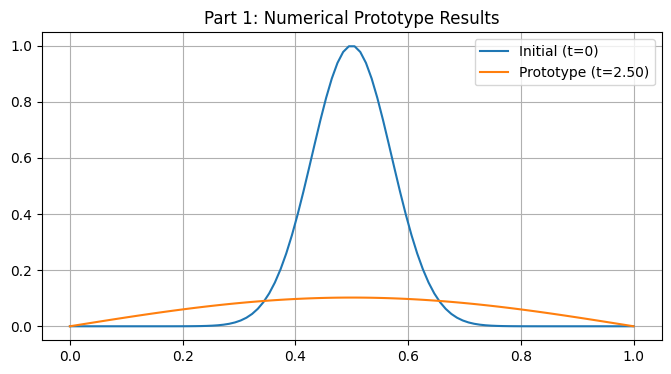

In [14]:
def thomas_solve_proto(a, b, c, d):
    """Standard TDMA solver for prototyped verification."""
    n = len(d)
    cp = np.zeros(n)
    dp = np.zeros(n)
    x_res = np.zeros(n)
    
    cp[0] = c[0] / b[0]
    dp[0] = d[0] / b[0]
    for i in range(1, n):
        m = 1.0 / (b[i] - a[i] * cp[i-1])
        cp[i] = c[i] * m
        dp[i] = (d[i] - a[i] * dp[i-1]) * m
    
    x_res[-1] = dp[-1]
    for i in range(n-2, -1, -1):
        x_res[i] = dp[i] - cp[i] * x_res[i+1]
    return x_res

def solve_implicit_proto(u_start, alpha, dx, dt, steps):
    """Source of truth Implicit solver prototype."""
    u_current = u_start.copy()
    r = alpha * dt / (dx**2)
    m = len(u_start) - 2
    
    a = np.full(m, -r)
    b = np.full(m, 1.0 + 2.0*r)
    c = np.full(m, -r)
    
    for _ in range(steps):
        d = u_current[1:-1].copy()
        # Add Dirichlet terms
        d[0] += r * u_current[0]
        d[-1] += r * u_current[-1]
        # Solve inner points
        u_current[1:-1] = thomas_solve_proto(a, b, c, d)
    return u_current

# Execute Development prototype
u_prototype = solve_implicit_proto(u0, alpha, dx, dt, steps)

plt.figure(figsize=(8, 4))
plt.plot(x, u0, label='Initial (t=0)')
plt.plot(x, u_prototype, label=f'Prototype (t={steps*dt:.2f})')
plt.title("Part 1: Numerical Prototype Results")
plt.legend()
plt.grid(True)
plt.show()

--- 
## Part 2: C++ Backend Verification
In this phase, we verify that the `cnt` (C++ implementation) yields identical results to the prototype developed above.

Successfully linked to cnt


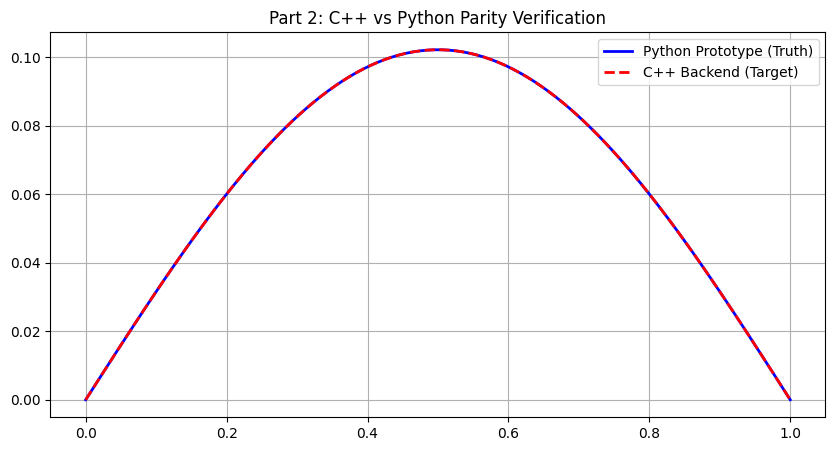

Max Absolute Error: 5.48e-16
✅ VERIFICATION SUCCESS: Backend matches prototype.


In [15]:
# Import C++ Backend
backend_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'backend'))
# Standard inplace path and build path support
for p in [os.path.abspath(os.path.join(backend_path, '..', 'interface', 'python')), os.path.join(backend_path, 'build')]:
    if p not in sys.path: sys.path.append(p)

try:
    import cnt
    print("Successfully linked to cnt")
except ImportError:
    print("Error: Build backend first using 'python setup.py build_ext --inplace' in the backend folder.")

# Run C++ Solver
cpp_model = cnt.Heat1DImplicit(nx, dx, alpha)
cpp_model.set_initial_condition(list(u0))
cpp_model.set_boundary_conditions(0.0, 0.0)

for _ in range(steps):
    cpp_model.step(dt)

u_cpp_target = np.array(cpp_model.get_values())

# Verification Analysis
plt.figure(figsize=(10, 5))
plt.plot(x, u_prototype, 'b-', linewidth=2, label='Python Prototype (Truth)')
plt.plot(x, u_cpp_target, 'r--', linewidth=2, label='C++ Backend (Target)')
plt.title("Part 2: C++ vs Python Parity Verification")
plt.legend()
plt.grid(True)
plt.show()

max_abs_error = np.max(np.abs(u_prototype - u_cpp_target))
print(f"Max Absolute Error: {max_abs_error:.2e}")
if max_abs_error < 1e-12:
    print("✅ VERIFICATION SUCCESS: Backend matches prototype.")
else:
    print("❌ VERIFICATION FAILED: Numerical divergence detected.")